In [1]:
%matplotlib inline
import boto3
import botocore
import datetime
import matplotlib.pyplot as plt
import matplotlib
import xarray as xr
import numpy as np
import s3fs
import fsspec
import dask
from dask.distributed import performance_report, Client, progress
import coiled
1601.82
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 18}
matplotlib.rc('font', **font)

In [2]:
cluster = coiled.Cluster(
    n_workers=0, 
    name="era5-access-arm",
    software="gefs-plot-arm-20230919-v5",
    #worker_memory="2 GiB",   # Memory allocated to each worker (sufficient based on your needs)
    #worker_cpu=1,   # Number of CPUs allocated to each worker (default is 1)
    scheduler_memory="8 GiB",   # Memory allocated to the scheduler (adjust as per your requirements)
    #scheduler_cpu=1, 
    region="us-east-1",          # Specific region
    arm=True,                    # Change architecture
    compute_purchase_option="spot",  # Use spot
    tags={"workload": "gefs-arm-test0"},   # Tag clusters
    worker_vm_types='t4g.small',
    #package_sync=True
)

Output()

## get the cluster 

In [3]:
#cluster = coiled.Cluster(name="era5-access-arm")
client = cluster.get_client()
client

/home/bulbul/micromamba/envs/panel-jupyter/lib/python3.11/site-packages/distributed/client.py:1389: VersionMismatchWarning: Mismatched versions found

+-------------+----------+-----------+----------+
| Package     | Client   | Scheduler | Workers  |
+-------------+----------+-----------+----------+
| dask        | 2023.9.1 | 2023.9.2  | 2023.9.2 |
| distributed | 2023.9.1 | 2023.9.2  | 2023.9.2 |
| numpy       | 1.24.4   | 1.26.0    | 1.26.0   |
+-------------+----------+-----------+----------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


<Client: 'tls://10.0.44.69:8786' processes=49 threads=98, memory=72.27 GiB>

In [4]:
##functions based on https://nbviewer.org/github/awslabs/amazon-asdi/blob/main/examples/dask/notebooks/era5_zarr.ipynb
def fix_accum_var_dims(ds, var):
    # Some varibles like precip have extra time bounds varibles, we drop them here to allow merging with other variables
    
    # Select variable of interest (drops dims that are not linked to current variable)
    ds = ds[[var]]  

    if var in ['air_temperature_at_2_metres',
               'dew_point_temperature_at_2_metres',
               'air_pressure_at_mean_sea_level',
               'northward_wind_at_10_metres',
               'eastward_wind_at_10_metres']:
        
        ds = ds.rename({'time0':'valid_time_end_utc'})
        
    elif var in ['precipitation_amount_1hour_Accumulation',
                 'integral_wrt_time_of_surface_direct_downwelling_shortwave_flux_in_air_1hour_Accumulation']:
        
        ds = ds.rename({'time1':'valid_time_end_utc'})
        
    else:
        print("Warning, Haven't seen {var} varible yet! Time renaming might not work.".format(var=var))
        
    return ds

@dask.delayed
def s3open(path):
    fs = s3fs.S3FileSystem(anon=True, default_fill_cache=False, 
                           config_kwargs = {'max_pool_connections': 20})
    return s3fs.S3Map(path, s3=fs)


def open_era5_range(start_year, end_year, variables):
    ''' Opens ERA5 monthly Zarr files in S3, given a start and end year (all months loaded) and a list of variables'''
    
    
    file_pattern = 'era5-pds/zarr/{year}/{month}/data/{var}.zarr/'
    
    years = list(np.arange(start_year, end_year+1, 1))
    months = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
    
    l = []
    for var in variables:
        print(var)
        
        # Get files
        files_mapper = [s3open(file_pattern.format(year=year, month=month, var=var)) for year in years for month in months]
        
        # Look up correct time dimension by variable name
        if var in ['precipitation_amount_1hour_Accumulation']:
            concat_dim='time1'
        else:
            concat_dim='time0'
            
        # Lazy load
        ds = xr.open_mfdataset(files_mapper, engine='zarr', 
                               concat_dim=concat_dim, combine='nested', 
                               coords='minimal', compat='override', parallel=True)
        
        # Fix dimension names
        ds = fix_accum_var_dims(ds, var)
        l.append(ds)
        
    ds_out = xr.merge(l)
    
    return ds_out



In [5]:
%%time

ds = open_era5_range(1979, 2022, ["air_temperature_at_2_metres"])

air_temperature_at_2_metres
CPU times: user 2.38 s, sys: 264 ms, total: 2.65 s
Wall time: 24.2 s


In [6]:
ds

<xarray.Dataset>
Dimensions:                      (valid_time_end_utc: 385704, lat: 721,
                                  lon: 1440)
Coordinates:
  * lat                          (lat) float32 90.0 89.75 89.5 ... -89.75 -90.0
  * lon                          (lon) float32 0.0 0.25 0.5 ... 359.5 359.8
  * valid_time_end_utc           (valid_time_end_utc) datetime64[ns] 1979-01-...
Data variables:
    air_temperature_at_2_metres  (valid_time_end_utc, lat, lon) float32 dask.array<chunksize=(372, 150, 150), meta=np.ndarray>
Attributes:
    institution:  ECMWF
    source:       Reanalysis
    title:        ERA5 forecasts

In [7]:
print('ds size in GB {:0.2f}\n'.format(ds.nbytes / 1e9))
ds.info

ds size in GB 1601.82



<bound method Dataset.info of <xarray.Dataset>
Dimensions:                      (valid_time_end_utc: 385704, lat: 721,
                                  lon: 1440)
Coordinates:
  * lat                          (lat) float32 90.0 89.75 89.5 ... -89.75 -90.0
  * lon                          (lon) float32 0.0 0.25 0.5 ... 359.5 359.8
  * valid_time_end_utc           (valid_time_end_utc) datetime64[ns] 1979-01-...
Data variables:
    air_temperature_at_2_metres  (valid_time_end_utc, lat, lon) float32 dask.array<chunksize=(372, 150, 150), meta=np.ndarray>
Attributes:
    institution:  ECMWF
    source:       Reanalysis
    title:        ERA5 forecasts>

In [8]:
ds['air_temperature_at_2_metres'] = (ds.air_temperature_at_2_metres - 273.15) 
ds.air_temperature_at_2_metres.attrs['units'] = 'Degree Celcius'

In [9]:
# calculates the mean along the time dimension
temp_mean = ds['air_temperature_at_2_metres'].mean(dim='valid_time_end_utc')


The expressions above didn’t actually compute anything. They just build the dask task graph. To do the computations, we call the persist method:

In [10]:
temp_mean = temp_mean.persist()
progress(temp_mean)


/home/bulbul/micromamba/envs/panel-jupyter/lib/python3.11/site-packages/distributed/client.py:3148: UserWarning: Sending large graph of size 12.31 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


VBox()

Text(0.5, 1.0, '1979-2020 Mean 2-m Air Temperature')

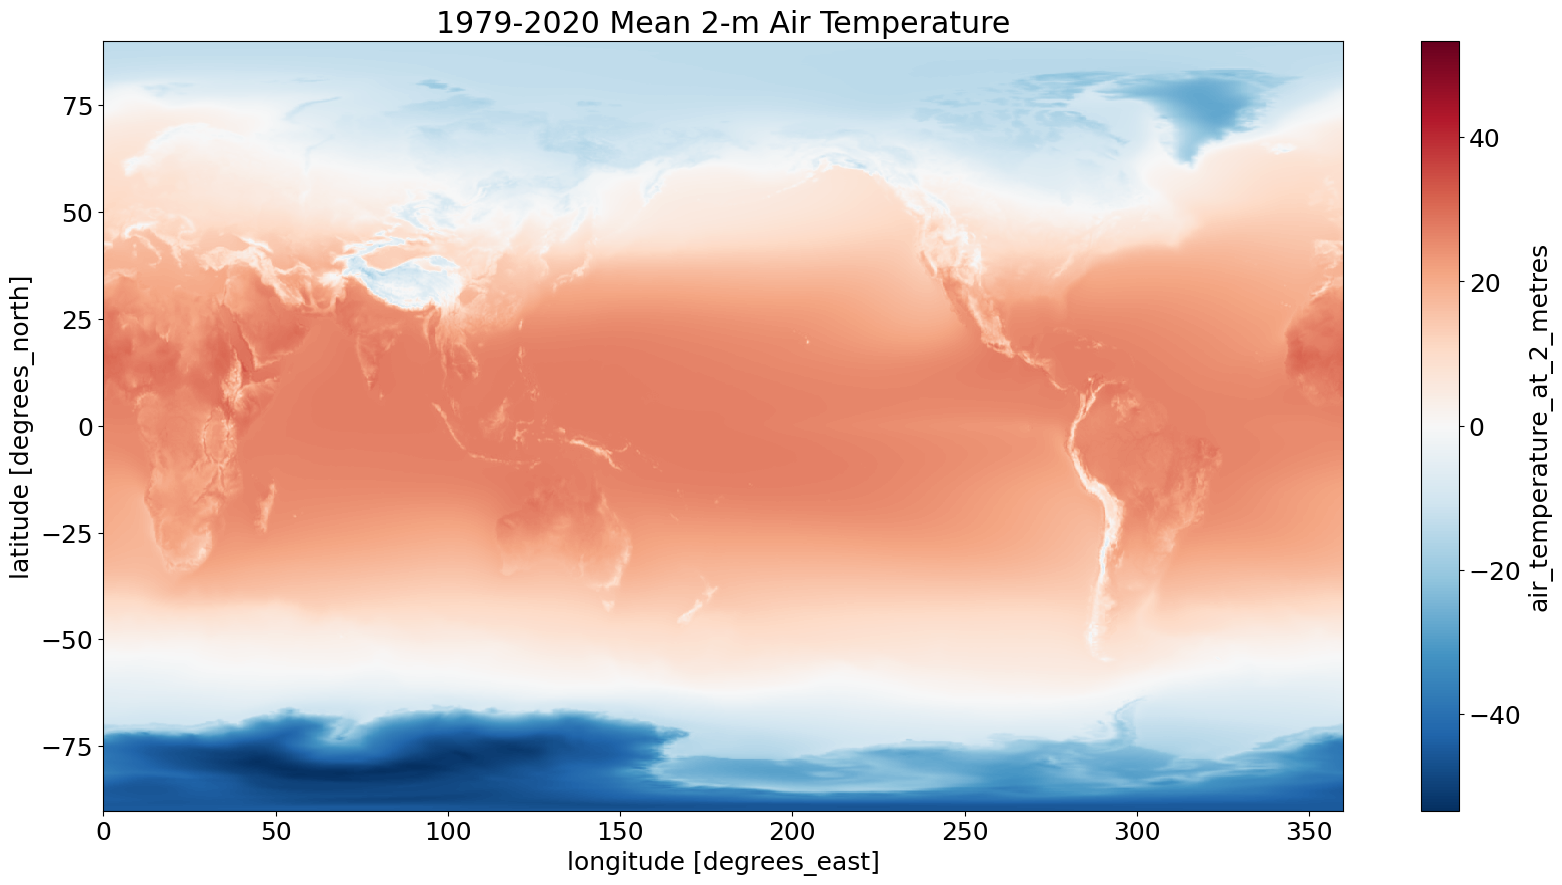

In [11]:
temp_mean.compute()
temp_mean.plot(figsize=(20, 10))
plt.title('1979-2020 Mean 2-m Air Temperature')


In [12]:
client.close()
cluster.shutdown()  